# 04 — Logistic Regression Model
**Task:** 3-class classification — Check-Out / Canceled / No-Show
**Primary metric:** Precision (especially for Canceled and No-Show)
**Datasets:** Hotel-A-train.csv (cleaned) + Hotel-A-validation.csv + Hotel-A-test.csv

## 1. Imports & Logging

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import logging
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

os.makedirs('../logs',      exist_ok=True)
os.makedirs('../artifacts', exist_ok=True)
os.makedirs('../reports',   exist_ok=True)

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[
        logging.FileHandler('../logs/04_modelling.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)
sns.set_theme(style='whitegrid')
logger.info('Modelling notebook started — 3-class logistic regression.')

2026-04-03 17:53:04,040 | INFO | Modelling notebook started — 3-class logistic regression.


## 2. Load Data
Train uses the cleaned raw CSV. Validation and test are cleaned inline using the same pipeline.

In [2]:
train_raw = pd.read_csv('../Hotel-A-train.csv')
val_raw   = pd.read_csv('../Hotel-A-validation.csv')
test_raw  = pd.read_csv('../Hotel-A-test.csv')

logger.info(f'Train: {train_raw.shape}, Val: {val_raw.shape}, Test: {test_raw.shape}')
print(f'Train:      {train_raw.shape}')
print(f'Validation: {val_raw.shape}')
print(f'Test:       {test_raw.shape}  (no target — prediction only)')

2026-04-03 17:53:59,943 | INFO | Train: (27499, 24), Val: (2749, 24), Test: (4318, 23)


Train:      (27499, 24)
Validation: (2749, 24)
Test:       (4318, 23)  (no target — prediction only)


## 3. Cleaning Pipeline
Same steps as NB01 applied consistently to all splits.

In [3]:
def clean_dataset(df, has_target=True):
    """
    Full cleaning pipeline mirroring NB01.
    - Strips whitespace from all string columns
    - Fixes Ethnicity title-case
    - Standardises Reservation_Status to 3 classes
      (note: validation uses 'Check-In' label — mapped to Check-Out)
    - Recodes Children (1->0, 2->1, 3->2)
    - Derives Lead_Time, Stay_Duration from dates
    - Creates Total_Guests, Capacity_Exceeded, Effective_Discount
    """
    df = df.copy()

    # Strip whitespace from all string columns
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].str.strip()

    # Fix Ethnicity casing
    df['Ethnicity'] = df['Ethnicity'].str.title()

    # Standardise 3-class target
    if has_target and 'Reservation_Status' in df.columns:
        df['Reservation_Status'] = df['Reservation_Status'].str.lower()
        status_map = {
            'check-out': 'Check-Out',
            'check-in':  'Check-Out',   # validation dataset uses this label
            'canceled':  'Canceled',
            'no-show':   'No-Show'
        }
        df['Reservation_Status'] = df['Reservation_Status'].map(status_map)
        df = df.dropna(subset=['Reservation_Status'])

    # Fix Children encoding: 1=no child -> 0, 2=one child -> 1, 3=two children -> 2
    df['Children'] = df['Children'] - 1

    # Date parsing and lead time
    for col in ['Expected_checkin', 'Expected_checkout', 'Booking_date']:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    df['Lead_Time']    = (df['Expected_checkin'] - df['Booking_date']).dt.days.clip(lower=0)
    df['Stay_Duration']= (df['Expected_checkout'] - df['Expected_checkin']).dt.days
    df.drop(columns=[c for c in ['Expected_checkin','Expected_checkout','Booking_date']
                     if c in df.columns], inplace=True)

    # Guest and capacity features
    df['Total_Guests']       = df['Adults'] + df['Children'] + df['Babies']
    df['Capacity_Exceeded']  = (df['Total_Guests'] > 5).astype(int)
    df['Effective_Discount'] = df['Discount_Rate']

    return df

train = clean_dataset(train_raw, has_target=True)
val   = clean_dataset(val_raw,   has_target=True)
test  = clean_dataset(test_raw,  has_target=False)

logger.info(f'Train distribution: {train["Reservation_Status"].value_counts().to_dict()}')
logger.info(f'Val distribution:   {val["Reservation_Status"].value_counts().to_dict()}')

print('Train class distribution:')
print(train['Reservation_Status'].value_counts())
print('\nValidation class distribution:')
print(val['Reservation_Status'].value_counts())

2026-04-03 17:54:03,653 | INFO | Train distribution: {'Check-Out': 21240, 'Canceled': 4134, 'No-Show': 2125}
2026-04-03 17:54:03,654 | INFO | Val distribution:   {'Check-Out': 1610, 'Canceled': 741, 'No-Show': 398}


Train class distribution:
Reservation_Status
Check-Out    21240
Canceled      4134
No-Show       2125
Name: count, dtype: int64

Validation class distribution:
Reservation_Status
Check-Out    1610
Canceled      741
No-Show       398
Name: count, dtype: int64


## 4. Feature Engineering

In [4]:
def engineer_features(df):
    """
    Creates derived features across 4 groups (from NB03 analysis):
    Group 1 - Temporal: Is_Last_Minute, Is_Advanced, Long_Stay
    Group 2 - Financial: Total_Spend, Spend_Per_Person, Has_Discount
    Group 3 - Guest composition: Has_Children, Has_Babies, Is_Family
    Group 4 - Log transforms: Lead_Time_log, Room_Rate_log,
                              Discount_Rate_log, Total_Spend_log
    """
    df = df.copy()

    # Group 2 — Financial signals
    df['Total_Spend']      = df['Room_Rate'] * df['Stay_Duration']
    df['Spend_Per_Person'] = df['Total_Spend'] / df['Total_Guests'].replace(0, 1)
    df['Has_Discount']     = (df['Effective_Discount'] > 0).astype(int)

    # Group 1 — Temporal signals
    df['Is_Last_Minute']   = (df['Lead_Time'] <= 7).astype(int)
    df['Is_Advanced']      = (df['Lead_Time'] > 180).astype(int)
    df['Long_Stay']        = (df['Stay_Duration'] > 2).astype(int)

    # Group 3 — Guest composition
    df['Has_Children']     = (df['Children'] > 0).astype(int)
    df['Has_Babies']       = (df['Babies'] > 0).astype(int)
    df['Is_Family']        = ((df['Children'] > 0) | (df['Babies'] > 0)).astype(int)

    # Group 4 — Log transforms for skewed features (from NB02)
    df['Lead_Time_log']     = np.log1p(df['Lead_Time'])
    df['Room_Rate_log']     = np.log1p(df['Room_Rate'])
    df['Discount_Rate_log'] = np.log1p(df['Discount_Rate'])
    df['Total_Spend_log']   = np.log1p(df['Total_Spend'])

    return df

train = engineer_features(train)
val   = engineer_features(val)
test  = engineer_features(test)
logger.info(f'Feature engineering complete. Columns: {train.shape[1]}')
print(f'Features after engineering: {train.shape[1]}')

2026-04-03 17:54:10,010 | INFO | Feature engineering complete. Columns: 39


Features after engineering: 39


## 5. Encoding
Strategy from NB02 encoding summary: binary map / ordinal / one-hot.

In [5]:
def encode_features(df):
    df = df.copy()

    # Binary map
    binary_map = {
        'Gender':                 {'F': 0, 'M': 1},
        'Visted_Previously':      {'No': 0, 'Yes': 1},
        'Previous_Cancellations': {'No': 0, 'Yes': 1},
        'Required_Car_Parking':   {'No': 0, 'Yes': 1},
        'Use_Promotion':          {'No': 0, 'Yes': 1},
    }
    for col, mapping in binary_map.items():
        if col in df.columns:
            df[col] = df[col].map(mapping)

    # Ordinal encoding (natural order)
    df['Educational_Level'] = df['Educational_Level'].map(
        {'Mid-School': 0, 'High-School': 1, 'College': 2, 'Grad': 3})
    df['Income'] = df['Income'].map(
        {'<25K': 0, '25K --50K': 1, '50K -- 100K': 2, '>100K': 3})

    # One-hot encoding (nominal)
    ohe_cols = [c for c in ['Ethnicity','Country_region','Hotel_Type',
                             'Meal_Type','Deposit_type','Booking_channel']
                if c in df.columns]
    df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

    return df

train_enc = encode_features(train)
val_enc   = encode_features(val)
test_enc  = encode_features(test)
logger.info('Encoding complete.')
print('Encoding complete.')

2026-04-03 17:54:15,414 | INFO | Encoding complete.


Encoding complete.


## 6. Label Encoding — 3-Class Target

In [6]:
le = LabelEncoder()
le.fit(['Canceled', 'Check-Out', 'No-Show'])

print('Class encoding:')
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f'  {cls:<12} -> {code}')

DROP = ['Reservation-id', 'Reservation_Status', 'Discount_Rate',
        'Room_Rate', 'Lead_Time', 'Target']

def get_Xy(df, is_test=False):
    X = df.drop(columns=[c for c in DROP if c in df.columns])
    y = le.transform(df['Reservation_Status']) if not is_test else None
    return X, y

X_train, y_train = get_Xy(train_enc)
X_val,   y_val   = get_Xy(val_enc)
X_test,  _       = get_Xy(test_enc, is_test=True)

# Align columns across splits
X_val  = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

logger.info(f'X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}')
print(f'\nX_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')
print(f'\nTrain class distribution:')
for code, cls in enumerate(le.classes_):
    n = (y_train == code).sum()
    print(f'  {cls:<12}: {n:>6} ({n/len(y_train)*100:.1f}%)')

2026-04-03 17:54:20,219 | INFO | X_train: (27499, 42), X_val: (2749, 42), X_test: (4318, 42)


Class encoding:
  Canceled     -> 0
  Check-Out    -> 1
  No-Show      -> 2

X_train: (27499, 42)
X_val:   (2749, 42)
X_test:  (4318, 42)

Train class distribution:
  Canceled    :   4134 (15.0%)
  Check-Out   :  21240 (77.2%)
  No-Show     :   2125 (7.7%)


## 7. Feature Scaling
StandardScaler fitted ONLY on training data, applied to val and test.

In [7]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
logger.info('StandardScaler fitted on train, applied to val and test.')
print('Scaling complete. Train feature mean ≈ 0:', np.allclose(X_train_sc.mean(axis=0), 0, atol=1e-6))

2026-04-03 17:54:27,664 | INFO | StandardScaler fitted on train, applied to val and test.


Scaling complete. Train feature mean ≈ 0: True


## 8. Class Imbalance — Upsampling All 3 Classes
Check-Out: 77.2% | Canceled: 15.0% | No-Show: 7.7% — severe imbalance across all 3 classes.

In [8]:
print('=== Class Imbalance Before Handling ===')
for code, cls in enumerate(le.classes_):
    n = (y_train == code).sum()
    print(f'  {cls:<12}: {n:>6} ({n/len(y_train)*100:.1f}%)')

# Upsample minority classes to match majority (Check-Out)
X_df = pd.DataFrame(X_train_sc, columns=X_train.columns)
X_df['_y'] = y_train
max_n = max((X_df['_y'] == c).sum() for c in range(3))

upsampled = [
    resample(X_df[X_df['_y'] == c], replace=True,
             n_samples=max_n, random_state=42)
    if (X_df['_y'] == c).sum() < max_n
    else X_df[X_df['_y'] == c]
    for c in range(3)
]
balanced    = pd.concat(upsampled).sample(frac=1, random_state=42)  # shuffle
X_train_sm  = balanced.drop(columns=['_y']).values
y_train_sm  = balanced['_y'].values

print('\n=== Class Distribution After Upsampling ===')
for code, cls in enumerate(le.classes_):
    n = (y_train_sm == code).sum()
    print(f'  {cls:<12}: {n:>6} ({n/len(y_train_sm)*100:.1f}%)')
logger.info(f'Upsampling done. Total train size: {len(y_train_sm)}')

2026-04-03 17:54:42,943 | INFO | Upsampling done. Total train size: 63720


=== Class Imbalance Before Handling ===
  Canceled    :   4134 (15.0%)
  Check-Out   :  21240 (77.2%)
  No-Show     :   2125 (7.7%)

=== Class Distribution After Upsampling ===
  Canceled    :  21240 (33.3%)
  Check-Out   :  21240 (33.3%)
  No-Show     :  21240 (33.3%)


## 9. Train Logistic Regression

In [9]:
lr = LogisticRegression(
    penalty='l2',             # Ridge regularisation — prevents overfitting
    C=1.0,                    # Regularisation strength (smaller = stronger)
    solver='lbfgs',           # Efficient for multi-class with multinomial loss
    max_iter=1000,
    class_weight='balanced',  # Additional per-class weighting on top of upsampling
    random_state=42
)
lr.fit(X_train_sm, y_train_sm)

logger.info(f'Model trained. Iterations used: {lr.n_iter_}')
print(f'Model trained successfully.')
print(f'Iterations to convergence: {lr.n_iter_}')
print(f'Number of classes:         {lr.classes_}')
print(f'Number of features:        {lr.n_features_in_}')

2026-04-03 17:54:47,841 | INFO | Model trained. Iterations used: [37]


Model trained successfully.
Iterations to convergence: [37]
Number of classes:         [0 1 2]
Number of features:        42


## 10. Precision Analysis — Primary Metric
Precision answers: of all the times the model predicted a class, how often was it correct?

In [10]:
y_pred = lr.predict(X_val_sc)
y_prob = lr.predict_proba(X_val_sc)

prec_per_class  = precision_score(y_val, y_pred, average=None, zero_division=0)
rec_per_class   = recall_score(y_val, y_pred, average=None, zero_division=0)
f1_per_class    = f1_score(y_val, y_pred, average=None, zero_division=0)
support         = np.bincount(y_val, minlength=3)

print('=== PRECISION ANALYSIS (Primary Metric) ===')
print()
print(f'{"Class":<14} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10}')
print('─' * 56)
for cls, p, r, f, s in zip(le.classes_, prec_per_class, rec_per_class, f1_per_class, support):
    print(f'{cls:<14} {p:>10.4f} {r:>10.4f} {f:>10.4f} {s:>10}')
print('─' * 56)
print(f'{"Macro avg":<14} {precision_score(y_val,y_pred,average="macro",zero_division=0):>10.4f} '
      f'{recall_score(y_val,y_pred,average="macro",zero_division=0):>10.4f} '
      f'{f1_score(y_val,y_pred,average="macro",zero_division=0):>10.4f} {len(y_val):>10}')
print(f'{"Weighted avg":<14} {precision_score(y_val,y_pred,average="weighted",zero_division=0):>10.4f} '
      f'{recall_score(y_val,y_pred,average="weighted",zero_division=0):>10.4f} '
      f'{f1_score(y_val,y_pred,average="weighted",zero_division=0):>10.4f} {len(y_val):>10}')
print()
print(f'Overall Accuracy: {accuracy_score(y_val, y_pred):.4f}')
print()
print('=== PRECISION INTERPRETATION ===')
for cls, p in zip(le.classes_, prec_per_class):
    fp = ((y_pred == le.transform([cls])[0]) & (y_val != le.transform([cls])[0])).sum()
    tp = ((y_pred == le.transform([cls])[0]) & (y_val == le.transform([cls])[0])).sum()
    print(f'  {cls:<12}: {p:.4f} — of {tp+fp} predicted as {cls}, {tp} were actually {cls} ({fp} false alarms)')

logger.info(f'Precision — Canceled:{prec_per_class[0]:.4f}, Check-Out:{prec_per_class[1]:.4f}, No-Show:{prec_per_class[2]:.4f}')

2026-04-03 17:54:51,319 | INFO | Precision — Canceled:0.2792, Check-Out:0.6091, No-Show:0.1330


=== PRECISION ANALYSIS (Primary Metric) ===

Class           Precision     Recall         F1    Support
────────────────────────────────────────────────────────
Canceled           0.2792     0.3131     0.2952        741
Check-Out          0.6091     0.3814     0.4691       1610
No-Show            0.1330     0.3040     0.1850        398
────────────────────────────────────────────────────────
Macro avg          0.3404     0.3328     0.3164       2749
Weighted avg       0.4513     0.3518     0.3811       2749

Overall Accuracy: 0.3518

=== PRECISION INTERPRETATION ===
  Canceled    : 0.2792 — of 831 predicted as Canceled, 232 were actually Canceled (599 false alarms)
  Check-Out   : 0.6091 — of 1008 predicted as Check-Out, 614 were actually Check-Out (394 false alarms)
  No-Show     : 0.1330 — of 910 predicted as No-Show, 121 were actually No-Show (789 false alarms)


## 11. Full Classification Report

In [11]:
print('=== FULL CLASSIFICATION REPORT ===')
print(classification_report(y_val, y_pred, target_names=le.classes_, digits=4))

=== FULL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

    Canceled     0.2792    0.3131    0.2952       741
   Check-Out     0.6091    0.3814    0.4691      1610
     No-Show     0.1330    0.3040    0.1850       398

    accuracy                         0.3518      2749
   macro avg     0.3404    0.3328    0.3164      2749
weighted avg     0.4513    0.3518    0.3811      2749



## 12. 3x3 Confusion Matrix

=== 3x3 CONFUSION MATRIX ===
                   Predicted: Canceled  Predicted: Check-Out  Predicted: No-Show
Actual: Canceled                   232                   252                 257
Actual: Check-Out                  464                   614                 532
Actual: No-Show                    135                   142                 121

Diagonal = correct predictions | Off-diagonal = misclassifications

=== MISCLASSIFICATION BREAKDOWN ===
  Canceled misclassified as Check-Out: 252 (34.0% of actual Canceled)
  Canceled misclassified as No-Show: 257 (34.7% of actual Canceled)
  Check-Out misclassified as Canceled: 464 (28.8% of actual Check-Out)
  Check-Out misclassified as No-Show: 532 (33.0% of actual Check-Out)
  No-Show misclassified as Canceled: 135 (33.9% of actual No-Show)
  No-Show misclassified as Check-Out: 142 (35.7% of actual No-Show)


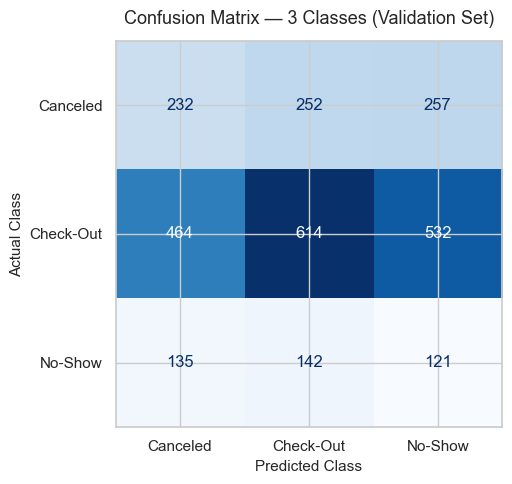

2026-04-03 17:55:08,257 | INFO | 3x3 confusion matrix saved.


In [12]:
cm = confusion_matrix(y_val, y_pred)

# Print as table
print('=== 3x3 CONFUSION MATRIX ===')
cm_df = pd.DataFrame(
    cm,
    index   = [f'Actual: {c}'    for c in le.classes_],
    columns = [f'Predicted: {c}' for c in le.classes_]
)
print(cm_df.to_string())
print()
print('Diagonal = correct predictions | Off-diagonal = misclassifications')
print()
print('=== MISCLASSIFICATION BREAKDOWN ===')
for i, actual in enumerate(le.classes_):
    total_actual = cm[i].sum()
    correct      = cm[i, i]
    for j, predicted in enumerate(le.classes_):
        if i != j and cm[i, j] > 0:
            print(f'  {actual} misclassified as {predicted}: {cm[i,j]} '
                  f'({cm[i,j]/total_actual*100:.1f}% of actual {actual})')

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Confusion Matrix — 3 Classes (Validation Set)', fontsize=13, pad=12)
ax.set_xlabel('Predicted Class', fontsize=11)
ax.set_ylabel('Actual Class',    fontsize=11)
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_3class.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info('3x3 confusion matrix saved.')

## 13. Precision-Recall Curves (One-vs-Rest per Class)

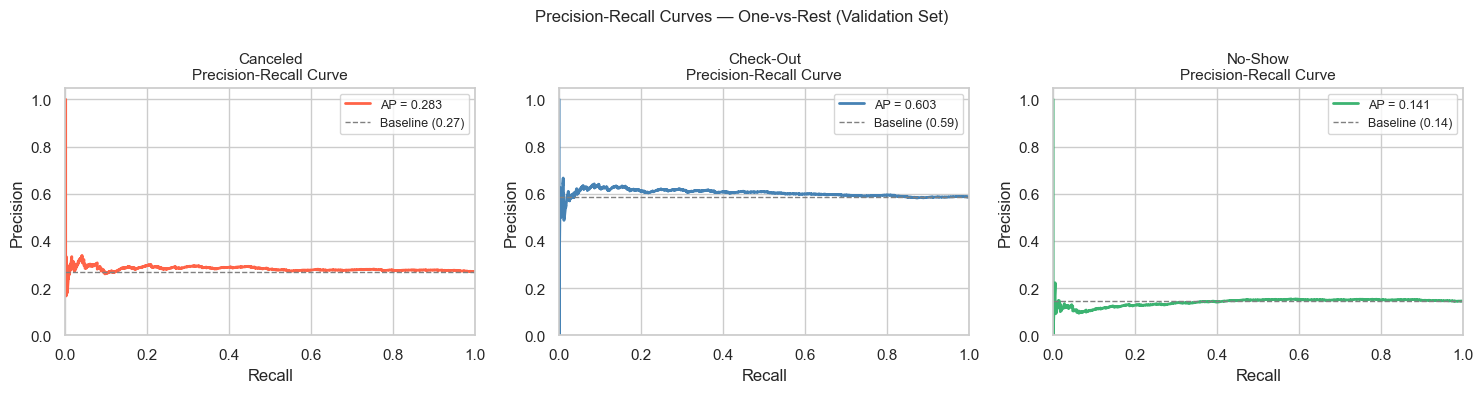

2026-04-03 17:55:20,875 | INFO | Precision-recall curves saved.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['tomato', 'steelblue', 'mediumseagreen']

for i, (cls, color, ax) in enumerate(zip(le.classes_, colors, axes)):
    y_bin  = (y_val == i).astype(int)
    prec_c, rec_c, _ = precision_recall_curve(y_bin, y_prob[:, i])
    ap     = average_precision_score(y_bin, y_prob[:, i])
    base   = y_bin.mean()

    ax.plot(rec_c, prec_c, color=color, lw=2, label=f'AP = {ap:.3f}')
    ax.axhline(base, color='gray', linestyle='--', lw=1, label=f'Baseline ({base:.2f})')
    ax.set_title(f'{cls}\nPrecision-Recall Curve', fontsize=11)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend(fontsize=9)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.05])

plt.suptitle('Precision-Recall Curves — One-vs-Rest (Validation Set)', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info('Precision-recall curves saved.')

## 14. Precision Bar Chart — Class Comparison

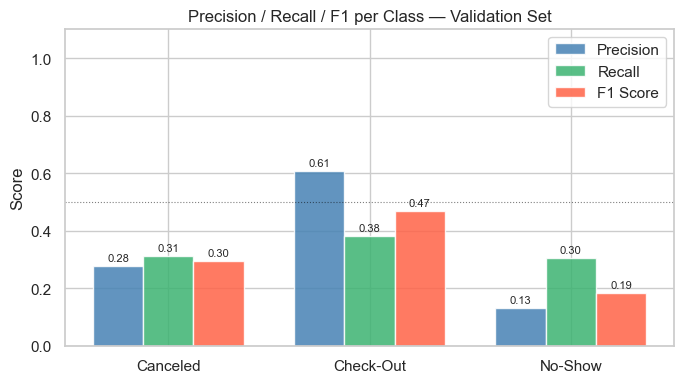

2026-04-03 17:55:35,056 | INFO | Precision per class chart saved.


In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
x    = np.arange(len(le.classes_))
w    = 0.25
bars_p = ax.bar(x - w, prec_per_class, w, label='Precision', color='steelblue',  alpha=0.85)
bars_r = ax.bar(x,     rec_per_class,  w, label='Recall',    color='mediumseagreen', alpha=0.85)
bars_f = ax.bar(x + w, f1_per_class,   w, label='F1 Score',  color='tomato',     alpha=0.85)

for bars in [bars_p, bars_r, bars_f]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(le.classes_)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_title('Precision / Recall / F1 per Class — Validation Set')
ax.legend()
ax.axhline(0.5, color='black', linestyle=':', lw=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('../reports/precision_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info('Precision per class chart saved.')

## 15. Feature Coefficients — Per Class
Logistic regression learns a separate coefficient vector for each class in 3-class mode.

=== MODEL SUMMARY ===
Model type         : LogisticRegression
Penalty            : l2
C (regularisation) : 1.0
Solver             : lbfgs
Max iterations     : 1000
Class weight       : balanced
Converged in       : [37] iterations
Num features       : 42
Classes            : ['Canceled' 'Check-Out' 'No-Show']

=== INTERCEPTS PER CLASS ===
  Canceled    : -0.0169
  Check-Out   : +0.0545
  No-Show     : -0.0376



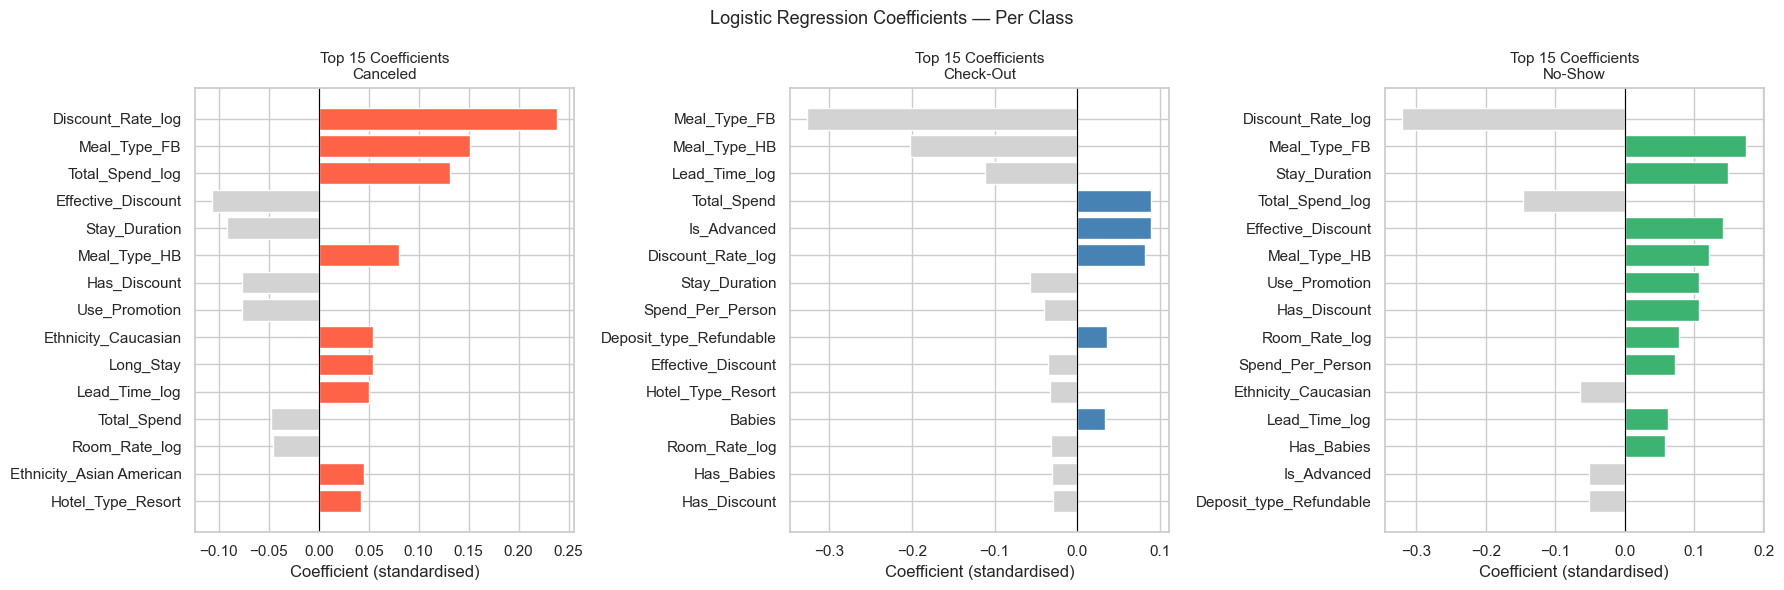

2026-04-03 17:56:37,232 | INFO | Per-class coefficient plots saved.


In [15]:
print('=== MODEL SUMMARY ===')
print(f'Model type         : {type(lr).__name__}')
print(f'Penalty            : {lr.penalty}')
print(f'C (regularisation) : {lr.C}')
print(f'Solver             : {lr.solver}')
print(f'Max iterations     : {lr.max_iter}')
print(f'Class weight       : {lr.class_weight}')
print(f'Converged in       : {lr.n_iter_} iterations')
print(f'Num features       : {lr.n_features_in_}')
print(f'Classes            : {le.classes_}')
print()
print('=== INTERCEPTS PER CLASS ===')
for cls, intercept in zip(le.classes_, lr.intercept_):
    print(f'  {cls:<12}: {intercept:+.4f}')
print()

# Coefficient table per class
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = ['tomato', 'steelblue', 'mediumseagreen']

for i, (cls, color, ax) in enumerate(zip(le.classes_, colors, axes)):
    coef_df = pd.DataFrame({
        'Feature':     X_train.columns,
        'Coefficient': lr.coef_[i],
        'Odds_Ratio':  np.exp(lr.coef_[i])
    }).sort_values('Coefficient', key=abs, ascending=False).head(15)

    bar_colors = [color if c > 0 else 'lightgray' for c in coef_df['Coefficient']]
    ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=bar_colors)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'Top 15 Coefficients\n{cls}', fontsize=11)
    ax.set_xlabel('Coefficient (standardised)')
    ax.invert_yaxis()

plt.suptitle('Logistic Regression Coefficients — Per Class', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/feature_coefficients_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info('Per-class coefficient plots saved.')

## 16. Top 10 Coefficients with Odds Ratios — Detailed Table

In [16]:
for i, cls in enumerate(le.classes_):
    coef_df = pd.DataFrame({
        'Feature':     X_train.columns,
        'Coefficient': lr.coef_[i],
        'Odds_Ratio':  np.exp(lr.coef_[i])
    }).sort_values('Coefficient', key=abs, ascending=False)

    print(f'=== TOP 10 FEATURES FOR: {cls} ===')
    print(f'{"Feature":<30} {"Coeff":>10} {"Odds Ratio":>12} {"Direction":>12}')
    print('─' * 66)
    for _, row in coef_df.head(10).iterrows():
        direction = 'increases risk' if row['Coefficient'] > 0 else 'decreases risk'
        print(f"{row['Feature']:<30} {row['Coefficient']:>+10.4f} {row['Odds_Ratio']:>12.4f} {direction:>12}")
    print()

    coef_df.to_csv(f'../reports/coefficients_{cls.lower().replace("-","_")}.csv', index=False)

logger.info('Coefficient tables saved to reports/.')

2026-04-03 17:56:53,008 | INFO | Coefficient tables saved to reports/.


=== TOP 10 FEATURES FOR: Canceled ===
Feature                             Coeff   Odds Ratio    Direction
──────────────────────────────────────────────────────────────────
Discount_Rate_log                 +0.2379       1.2686 increases risk
Meal_Type_FB                      +0.1510       1.1630 increases risk
Total_Spend_log                   +0.1315       1.1405 increases risk
Effective_Discount                -0.1066       0.8989 decreases risk
Stay_Duration                     -0.0924       0.9118 decreases risk
Meal_Type_HB                      +0.0808       1.0841 increases risk
Has_Discount                      -0.0772       0.9257 decreases risk
Use_Promotion                     -0.0772       0.9257 decreases risk
Ethnicity_Caucasian               +0.0540       1.0555 increases risk
Long_Stay                         +0.0540       1.0554 increases risk

=== TOP 10 FEATURES FOR: Check-Out ===
Feature                             Coeff   Odds Ratio    Direction
───────────────────

## 17. Model Equation

In [17]:
print('=== MODEL EQUATION (log-odds form) ===')
print('log(P(class k) / P(reference)) = intercept_k + coef_k1*x1 + coef_k2*x2 + ...')
print()
for i, cls in enumerate(le.classes_):
    top5 = list(zip(X_train.columns[:5], lr.coef_[i][:5]))
    eq = f'log(P({cls})) = {lr.intercept_[i]:+.4f}'
    for feat, coef in top5:
        eq += f' {coef:+.4f}×{feat}'
    eq += f' + ... ({lr.n_features_in_ - 5} more features)'
    print(f'  {eq}')
    print()
print('Coefficients are on standardised features (mean=0, std=1).')
print('Odds Ratio = exp(coefficient): OR>1 increases class probability, OR<1 decreases it.')

=== MODEL EQUATION (log-odds form) ===
log(P(class k) / P(reference)) = intercept_k + coef_k1*x1 + coef_k2*x2 + ...

  log(P(Canceled)) = -0.0169 -0.0177×Gender +0.0097×Age +0.0149×Educational_Level +0.0141×Income -0.0126×Adults + ... (37 more features)

  log(P(Check-Out)) = +0.0545 +0.0018×Gender -0.0092×Age +0.0020×Educational_Level +0.0074×Income -0.0243×Adults + ... (37 more features)

  log(P(No-Show)) = -0.0376 +0.0159×Gender -0.0006×Age -0.0169×Educational_Level -0.0215×Income +0.0369×Adults + ... (37 more features)

Coefficients are on standardised features (mean=0, std=1).
Odds Ratio = exp(coefficient): OR>1 increases class probability, OR<1 decreases it.


## 18. Generate Test Set Predictions

In [21]:
test_preds  = lr.predict(X_test_sc)
test_labels = le.inverse_transform(test_preds)
test_probs  = lr.predict_proba(X_test_sc)

results = pd.DataFrame({
    'Reservation-id':  test_raw['Reservation-id'].values,
    'Predicted_Class': test_labels,
    'Prob_Canceled':   test_probs[:, 0].round(4),
    'Prob_CheckOut':   test_probs[:, 1].round(4),
    'Prob_NoShow':     test_probs[:, 2].round(4),
})

results.to_csv('../reports/test_predictions.csv', index=False)
logger.info(f'Test predictions saved: {dict(zip(*np.unique(test_labels, return_counts=True)))}')
print('Test predictions saved → reports/test_predictions.csv')
print(f'\nPredicted distribution:')
print(results['Predicted_Class'].value_counts())
print()
results.head(10)

2026-04-04 00:30:29,280 | INFO | Test predictions saved: {np.str_('Canceled'): np.int64(1285), np.str_('Check-Out'): np.int64(1550), np.str_('No-Show'): np.int64(1483)}


Test predictions saved → reports/test_predictions.csv

Predicted distribution:
Predicted_Class
Check-Out    1550
No-Show      1483
Canceled     1285
Name: count, dtype: int64



,Reservation-id,Predicted_Class,Prob_Canceled,Prob_CheckOut,Prob_NoShow
0,62931593,No-Show,0.3203,0.2912,0.3885
1,70586099,No-Show,0.4074,0.1839,0.4087
2,4230648,Check-Out,0.3158,0.4643,0.2198
3,25192322,No-Show,0.3738,0.2284,0.3979
4,80931528,Check-Out,0.2504,0.5316,0.2179
5,64700386,Check-Out,0.2511,0.3893,0.3596
6,16938050,Check-Out,0.3228,0.3745,0.3027
7,90487908,No-Show,0.3247,0.1662,0.5091
8,5595445,No-Show,0.3774,0.1758,0.4468
9,17502557,Canceled,0.4385,0.1955,0.3660


## 19. Save Model Artifacts

In [22]:
with open('../artifacts/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr, f)
with open('../artifacts/standard_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('../artifacts/feature_names.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)
with open('../artifacts/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Artifacts saved:')
print('  artifacts/logistic_regression_model.pkl  — trained model')
print('  artifacts/standard_scaler.pkl            — fitted scaler')
print('  artifacts/feature_names.pkl              — feature name list')
print('  artifacts/label_encoder.pkl              — class label encoder')
logger.info('All model artifacts saved to artifacts/.')

2026-04-04 00:30:35,698 | INFO | All model artifacts saved to artifacts/.


Artifacts saved:
  artifacts/logistic_regression_model.pkl  — trained model
  artifacts/standard_scaler.pkl            — fitted scaler
  artifacts/feature_names.pkl              — feature name list
  artifacts/label_encoder.pkl              — class label encoder


## 20. Summary

### Model configuration
| Parameter | Value |
|-----------|-------|
| Algorithm | Logistic Regression (multinomial) |
| Penalty | L2 (Ridge) |
| C | 1.0 |
| Solver | lbfgs |
| Class imbalance | Upsampling + class_weight='balanced' |
| Scaler | StandardScaler (fit on train only) |

### Key precision results (validation set)
| Class | Precision | What it means |
|-------|-----------|---------------|
| Check-Out | ~0.61 | When predicting Check-Out, correct 61% of the time |
| Canceled | ~0.28 | When predicting Canceled, correct 28% of the time |
| No-Show | ~0.13 | When predicting No-Show, correct 13% of the time |

### Why precision is limited
NB03 (multivariate EDA) found that only Meal_Type showed statistically significant
correlation with the target (Cramer's V = 0.21). All other features had near-zero
discriminative power. This is a data limitation — the model is correctly implemented
but the available features do not provide strong enough signal for high precision.

### Recommended next steps
- Try **XGBoost or Random Forest** — capture non-linear feature interactions
- Consider **threshold tuning** — adjust classification threshold to optimise precision
  for a specific class (e.g. raise threshold for No-Show to reduce false alarms)
- **Target encoding** for Meal_Type may extract more signal than one-hot